In [1]:
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import fastplot
import numpy as np
import seaborn as sns
import os
import json

%matplotlib inline

In [2]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-03-06')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa = (
    df
        .set_index('asn_customer')
        ['providers']
        .apply(lambda prov: set(prov.replace('AS', '').split(' ')))
        .to_dict()
)

ASPA_CUSTOMERS = set(aspa.keys())

In [ ]:
### Get aspa_vis, ~3 minutes

if os.path.exists('data/aspa_vis.json'):
    with open('data/aspa_vis.json', 'r') as f:
        aspa_vis = json.load(f)
        
    aspa_vis = {k: set(v) for k, v in aspa_vis.items()}

else:
    adjacent_asns = { customer: set() for customer in ASPA_CUSTOMERS }
    with open('data/caida/2026-03-paths-sort-u.psv', 'r') as f:
        for line in f:
            path_str = line.strip()
            path = path_str.split('|')
            if len(set(path) & ASPA_CUSTOMERS) == 0:
                continue
            
            for i, asn in enumerate(path):
                if asn in ASPA_CUSTOMERS:
                    if i > 0:
                        adjacent_asns[asn].add(path[i - 1])
                    if i < len(path) - 1:
                        adjacent_asns[asn].add(path[i + 1])

    aspa_vis = { 
        customer: aspa[customer] & adjacent_asns[customer] 
        for customer in ASPA_CUSTOMERS 
    }

    with open('data/aspa_vis.json', 'w') as f:
        json.dump({k: list(v) for k, v in aspa_vis.items()}, f, indent=4)

In [4]:
_caida_prov_4 = (
    pd
        .read_csv('data/caida/2026-03-as-rel-v4.txt', 
                             sep='|', comment='#', header=None,  
                             names=['provider', 'customer', 'rel'],
                             dtype={'provider': str, 'customer': str, 'rel': int}
                 )
        .query('rel != 0')
        .query('customer in @ASPA_CUSTOMERS')
        .groupby('customer')
        ['provider']
        .agg(set)
        .to_dict()
)

_caida_prov_6 = (
    pd
        .read_csv('data/caida/2026-03-as-rel-v6.txt', 
                             sep='|', comment='#', header=None,  
                             names=['provider', 'customer', 'rel'],
                             dtype={'provider': str, 'customer': str, 'rel': int}
                 )
        .query('rel != 0')
        .query('customer in @ASPA_CUSTOMERS')
        .groupby('customer')
        ['provider']
        .agg(set)
        .to_dict()
)

caida = dict()
for customer in ASPA_CUSTOMERS:
    caida[customer] = set()
    caida[customer] |= _caida_prov_4.get(customer, set())
    caida[customer] |= _caida_prov_6.get(customer, set())

_bgpkit_prov_list = list()
for day in ('01', '02', '03', '04', '05'):
    _bgpkit_prov = (
        pd
            .read_json(f'data/bgpkit/as-rel_2026-03-{day}.json', dtype={'asn1': str, 'asn2': str})
            [['asn1', 'asn2', 'rel']]
            .rename(columns={'asn1': 'provider', 'asn2': 'customer'})
            .query('rel != 0')
            .query('customer in @ASPA_CUSTOMERS')
            .groupby('customer')
            ['provider']
            .agg(set)
            .to_dict()
    )
    _bgpkit_prov_list.append(_bgpkit_prov)

bgpkit = { customer: set() for customer in ASPA_CUSTOMERS }
for d in _bgpkit_prov_list:
    for customer, providers in d.items():
        bgpkit[customer] |= providers

In [5]:
CAIDA_SET = r"\textbf{\textsf{CAIDA}}"
BGPKIT_SET = r"\textbf{\textsf{BGPKIT}}"
ASPA_SET = r"\textbf{\textsf{ASPA}}"
ASPAVIS_SET = r"\textbf{\textsf{ASPA}\textsubscript{\textsf{vis}}}"

# Provider sets size comparison

<Figure size 640x480 with 0 Axes>

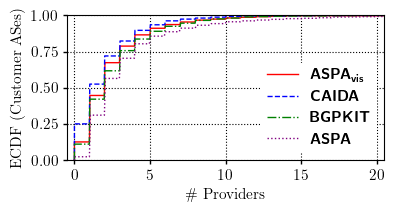

In [6]:
fastplot.plot([(ASPAVIS_SET, [len(v - {'0',}) for v in aspa_vis.values()]), 
                   (CAIDA_SET, [len(v) for v in caida.values()]), 
                   (BGPKIT_SET, [len(v) for v in bgpkit.values()]),
                   (ASPA_SET, [len(v - {'0',}) for v in aspa.values()])],
                  path=None, grid=True,
                  mode='CDF_multi', style='latex',
                  xtick_direction='out', ytick_direction='out',
                  legend=True, legend_loc='lower right', 
                  xlim=(-0.5, 20.5),
                  xlabel=r'\# Providers', ylabel='ECDF (Customer ASes)')

plt.savefig('figures/cdf_num_providers.pdf')

<Figure size 640x480 with 0 Axes>

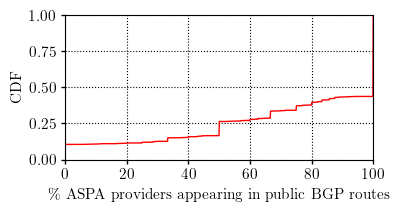

In [8]:
plot_data = list()

for customer, providers in aspa.items():
    if len(providers - {'0',}) == 0:
        continue
    plot_data.append(len(providers & aspa_vis[customer]) / len(providers) * 100)

fastplot.plot(plot_data, path=None, mode='CDF', style='latex', 
              xlabel=r'\% ASPA providers appearing in public BGP routes', 
              grid=True, xtick_direction='out', ytick_direction='out').show()

# Overall accuracy

In [ ]:
# Overall precision / recall / F1 score, both against aspa and against aspa_vis
for dataset in ('CAIDA', 'BGPKIT'):
    if dataset == 'CAIDA':
        infer_prov = caida
    elif dataset == 'BGPKIT':
        infer_prov = bgpkit
    
    tp = sum(len(infer_prov[c] & aspa[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fp = sum(len(infer_prov[c] - aspa[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fn = sum(len(aspa[c] - infer_prov[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{dataset} vs ASPA: Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")
    
    tp_star = sum(len(infer_prov[c] & aspa_vis[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fp_star = sum(len(infer_prov[c] - aspa_vis[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    fn_star = sum(len(aspa_vis[c] - infer_prov[c]) for c in ASPA_CUSTOMERS if len(aspa_vis[c]) > 0)
    
    precision_star = tp_star / (tp_star + fp_star) if (tp_star + fp_star) > 0 else 0
    recall_star = tp_star / (tp_star + fn_star) if (tp_star + fn_star) > 0 else 0
    f1_star = 2 * (precision_star * recall_star) / (precision_star + recall_star) if (precision_star + recall_star) > 0 else 0
    
    print(f"{dataset} vs ASPA*: Precision={precision_star:.2f}, Recall={recall_star:.2f}, F1={f1_star:.2f}")

CAIDA vs ASPA: Precision=0.88, Recall=0.54, F1=0.67
CAIDA vs ASPA*: Precision=0.88, Recall=0.71, F1=0.79
BGPKIT vs ASPA: Precision=0.88, Recall=0.71, F1=0.78
BGPKIT vs ASPA*: Precision=0.87, Recall=0.93, F1=0.90


## Deep dive in false positives
1. Are they consistent with genuine customer-to-provider relationships?
2. Do they become true positives when accounting for updated ASPA objects?

In [10]:
fps_per_customer = {
    dataset: {
        c: (caida[c] - aspa[c]) if dataset == 'CAIDA' else (bgpkit[c] - aspa[c])
        for c in ASPA_CUSTOMERS
    }
    for dataset in ('CAIDA', 'BGPKIT')
}

In [18]:
TIER_1_ASES = {
    # The list of Tier 1 ASes is obtained from https://bgp.tools/kb/what-is-a-upstream
    "174",   # Cogent
    "701",   # Verizon
    "1299",  # Arelion
    "2914",  # NTT
    "3257",  # GTT
    "3320",  # DTAG
    "3356",  # Lumen
    "3491",  # PCCW
    "5511",  # Orange
    "6453",  # TATA
    "6461",  # Zayo
    "6762",  # Sparkle
    "6830",  # Liberty Global
    "6939",  # HE (IPv6)
    "7018",  # AT&T
    "12956"  # Telefonica
}

# invalid_paths = set()
# with open('invalid_paths.txt', 'r') as f:
#     for line in f:
#         invalid_paths.add(line.strip())

all_paths = set()
with open('AS_paths.txt', 'r') as f:
    for line in f:
        all_paths.add(line.strip())

results = {}  # dataset -> {AS-C -> set of FPs matching either form}

for dataset in ('CAIDA', 'BGPKIT'):
    infer_prov = caida if dataset == 'CAIDA' else bgpkit
    dataset_results = {}

    matched_fps = set()

    for path_str in all_paths:
        path = path_str.split('|')
        for i, asn in enumerate(path):
            if asn not in ASPA_CUSTOMERS:
                continue

            fps = fps_per_customer[dataset][asn]
            if len(fps) == 0:
                continue

            # Form 1: path[i]=AS-C, path[i+1]=FP, Tier-1 somewhere after i+1
            if i + 1 < len(path) and path[i + 1] in fps:
                fp = path[i + 1]
                if any(k in TIER_1_ASES for k in path[i + 1:]):
                    matched_fps.add((asn, fp))

            # Form 2: path[i-1]=FP, path[i]=AS-C, Tier-1 somewhere before i-1
            if i - 1 >= 0 and path[i - 1] in fps:
                fp = path[i - 1]
                if any(k in TIER_1_ASES for k in path[:i]):
                    matched_fps.add((asn, fp))

    results[dataset] = matched_fps


print(
    f"CAIDA: {len(results['CAIDA'])} matched FPs "
    f"out of {sum(len(v) for v in fps_per_customer['CAIDA'].values())} total FPs "
    f"affecting {len(set(c for c, _ in results['CAIDA']))} Customer ASes"
)
print(
    f"BGPKIT: {len(results['BGPKIT'])} matched FPs "
    f"out of {sum(len(v) for v in fps_per_customer['BGPKIT'].values())} total FPs "
    f"affecting {len(set(c for c, _ in results['BGPKIT']))} Customer ASes"
)

CAIDA: 124 matched FPs out of 311 total FPs affecting 92 Customer ASes
BGPKIT: 371 matched FPs out of 431 total FPs affecting 253 Customer ASes


In [19]:
df = pd.read_csv('data/vaps.csv')
df['date'] = pd.to_datetime(df['date'])

df = df[(df['date'] >= '2026-03-01') & (df['date'] < '2026-04-01')]
df = df.drop_duplicates('customer', keep='last')

df['asn_customer'] = df['customer'].apply(lambda s: s[2:])

aspa_updated = (
    df
        .set_index('asn_customer')
        ['providers']
        .apply(lambda prov: set(prov.replace('AS', '').split(' ')))
        .to_dict()
)

caida_updated_positives = 0
bgpkit_updated_positives = 0

for c, fps in fps_per_customer['CAIDA'].items():
    for fp in fps:
        if fp in aspa_updated[c]:
            caida_updated_positives += 1


for c, fps in fps_per_customer['BGPKIT'].items():
    for fp in fps:
        if fp in aspa_updated[c]:
            bgpkit_updated_positives += 1

print(f"CAIDA false positives that are actually true positives in updated ASPA objects: {caida_updated_positives}")
print(f"BGPKIT false positives that are actually true positives in updated ASPA objects: {bgpkit_updated_positives}")

CAIDA false positives that are actually true positives in updated ASPA objects: 7
BGPKIT false positives that are actually true positives in updated ASPA objects: 14


# Per-AS accuracy

In [ ]:
def get_heatmap_data(dataset, aspa_adjusted=False):
    inferred_providers = dict()
    
    if dataset.upper() == 'CAIDA':
        inferred_providers = caida
    elif dataset.upper() == 'BGPKIT':
        inferred_providers = bgpkit
    else:
        return dict()

    data = Counter()

    if aspa_adjusted:
        for customer, aspa_prov in aspa_vis.items():
            if len(aspa_vis[customer] - {'0',}) == 0:
                continue
            infer_prov = inferred_providers[customer]
            x = len(aspa_prov - infer_prov) # false negatives (ASPA providers missed by inference)
            y = len(infer_prov - aspa_prov) # false positives (Inferred providers not in ASPA)
            data[(x, y)] += 1
    else:
        for customer, aspa_prov in aspa.items():
            if len(aspa_vis[customer] - {'0',}) == 0:
                continue
            infer_prov = inferred_providers[customer]
            x = len(aspa_prov - infer_prov) # false negatives (ASPA providers missed by inference)
            y = len(infer_prov - aspa_prov) # false positives (Inferred providers not in ASPA)
            data[(x, y)] += 1

    return data

## One figure with 4 heatmap subplots

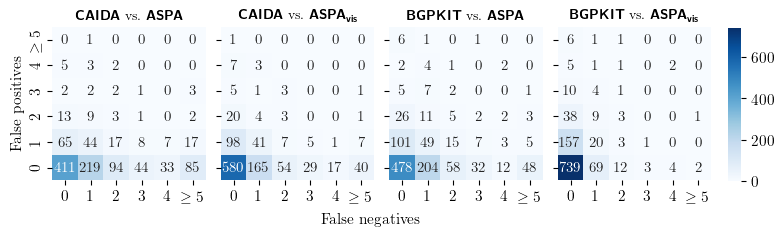

In [ ]:
XLIM = 4  # values >= 5 are aggregated in the last column
YLIM = 4  # values >= 5 are aggregated in the last row


def build_heatmap_matrix(dataset, aspa_adjusted, xlim=XLIM, ylim=YLIM):
    data = get_heatmap_data(dataset, aspa_adjusted=aspa_adjusted)
    matrix = np.zeros((ylim + 2, xlim + 2))

    for (x, y), count in data.items():
        xi = x if x <= xlim else xlim + 1
        yi = y if y <= ylim else ylim + 1
        matrix[yi, xi] += count

    return matrix

configs: list[tuple[str, bool, str]] = [
    ('CAIDA', False, fr'{CAIDA_SET} vs.\ {ASPA_SET}'),
    ('CAIDA', True, fr'{CAIDA_SET} vs.\ {ASPAVIS_SET}'),
    ('BGPKIT', False, fr'{BGPKIT_SET} vs.\ {ASPA_SET}'),
    ('BGPKIT', True, fr'{BGPKIT_SET} vs.\ {ASPAVIS_SET}'),
]

matrices = [build_heatmap_matrix(dataset, adjusted) for dataset, adjusted, _ in configs]
vmax = max(matrix.max() for matrix in matrices)

# decrease space between subplots
fig, axes = plt.subplots(1, 4, figsize=(8.5, 2.5), sharey=True, squeeze=True)
plt.subplots_adjust(wspace=0.1, right=0.9)

cbar_ax = fig.add_axes([0.92, 0.185, 0.015, 0.612])

fig.text(0.5, 0.06, 'False negatives', ha='center', va='top')

for i, (ax, matrix, (_, _, title)) in enumerate(zip(axes, matrices, configs)):
    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        cmap='Blues',
        fmt='.3g',
        vmin=0,
        annot_kws={'fontsize': 10.75},
        vmax=vmax,
        square=True,
        cbar=(i == len(axes) - 1),
        cbar_ax=cbar_ax if i == len(axes) - 1 else None,
    )
    
    ax.invert_yaxis()
    ax.set_xticks(np.arange(XLIM + 2) + 0.5)
    ax.set_xticklabels([str(j) for j in range(XLIM + 1)] + [rf'$\ge {XLIM + 1}$'])
    ax.set_yticks(np.arange(YLIM + 2) + 0.5)
    ax.set_yticklabels([str(j) for j in range(YLIM + 1)] + [rf'$\ge {YLIM + 1}$'])

    ax.set_title(title, fontsize=10)


    ax.set_ylabel('False positives' if i == 0 else '')

plt.savefig('figures/combined_heatmap.pdf', bbox_inches='tight', pad_inches=0.1)